# Q1: k-Nearest Neighbours from Scratch - BSDS500 Boundary Detection

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from scipy.io import loadmat

BASE = "/home/claude/dataset"
IMAGE_EXTENSIONS = (".jpg", ".jpeg", ".png")
IMAGES_TRAIN = os.path.join(BASE, "images", "train")
IMAGES_VAL = os.path.join(BASE, "images", "val")
IMAGES_TEST = os.path.join(BASE, "images", "test")
GT_TRAIN = os.path.join(BASE, "ground_truth", "train")
GT_VAL = os.path.join(BASE, "ground_truth", "val")
GT_TEST = os.path.join(BASE, "ground_truth", "test")

### Helper functions for loading images and ground truth

In [2]:
def list_image_files(images_dir, max_images):
    filenames = sorted(f for f in os.listdir(images_dir) if f.lower().endswith(IMAGE_EXTENSIONS))
    return filenames[:max_images]

def find_gt_path(gt_dir, image_filename):
    stem = os.path.splitext(image_filename)[0]
    candidate = os.path.join(gt_dir, stem + ".mat")
    if not os.path.exists(candidate):
        raise FileNotFoundError(
            f"No matching ground-truth .mat file found for image '{image_filename}' "
            f"(expected {candidate})"
        )
    return candidate

def load_bsds_ground_truth(mat_path):
    mat = loadmat(mat_path)
    gt_struct = mat["groundTruth"]
    n_annotators = gt_struct.shape[1]
    boundary_maps = [np.asarray(gt_struct[0, i]["Boundaries"][0, 0], dtype=float)
                      for i in range(n_annotators)]
    consensus = np.mean(boundary_maps, axis=0)
    return (consensus >= 0.5).astype(int)

def get_boundary_labels(gt_array):
    unique_vals = np.unique(gt_array)
    if len(unique_vals) <= 2:
        return (gt_array > 0).astype(int)
    diff_right = gt_array[:, :-1] != gt_array[:, 1:]
    diff_down = gt_array[:-1, :] != gt_array[1:, :]
    boundary = np.zeros_like(gt_array, dtype=bool)
    boundary[:, :-1] |= diff_right
    boundary[:-1, :] |= diff_down
    return boundary.astype(int)

def extract_pixel_features(img_array):
    gray = img_array.mean(axis=2)
    grad_y = np.abs(np.diff(gray, axis=0, prepend=gray[:1, :]))
    grad_x = np.abs(np.diff(gray, axis=1, prepend=gray[:, :1]))
    grad_mag = np.sqrt(grad_x ** 2 + grad_y ** 2)
    feats = np.stack([img_array[:, :, 0], img_array[:, :, 1], img_array[:, :, 2], gray, grad_mag], axis=-1)
    return feats.reshape(-1, 5)

def load_pixel_dataset(images_dir, gt_dir, max_images, pixels_per_image, seed=0):
    rng = np.random.RandomState(seed)
    filenames = list_image_files(images_dir, max_images)
    X_parts, y_parts = [], []
    total_pixels = 0
    for fname in filenames:
        img = np.array(Image.open(os.path.join(images_dir, fname)).convert("RGB"), dtype=float) / 255.0
        gt_path = find_gt_path(gt_dir, fname)
        gt = load_bsds_ground_truth(gt_path)
        if gt.shape != img.shape[:2]:
            raise ValueError(
                f"Ground truth shape {gt.shape} does not match image shape "
                f"{img.shape[:2]} for '{fname}'"
            )
        labels_full = get_boundary_labels(gt).reshape(-1)
        feats_full = extract_pixel_features(img)
        total_pixels += labels_full.shape[0]
        boundary_idx = np.where(labels_full == 1)[0]
        nonboundary_idx = np.where(labels_full == 0)[0]
        rng.shuffle(boundary_idx)
        rng.shuffle(nonboundary_idx)
        idx = np.concatenate([boundary_idx[:pixels_per_image], nonboundary_idx[:pixels_per_image]])
        X_parts.append(feats_full[idx])
        y_parts.append(labels_full[idx])
    X = np.vstack(X_parts)
    y = np.concatenate(y_parts)
    return X, y, total_pixels, len(filenames)

feature_names = ["R", "G", "B", "gray", "gradient_magnitude"]

### Load training and test pixel samples

In [3]:
X_train, y_train, total_train_pixels, n_train_images = load_pixel_dataset(
    IMAGES_TRAIN, GT_TRAIN, max_images=40, pixels_per_image=250, seed=0)
X_test, y_test, total_test_pixels, n_test_images = load_pixel_dataset(
    IMAGES_TEST, GT_TEST, max_images=15, pixels_per_image=150, seed=1)

print("Training images used:", n_train_images, " total pixels in those images:", total_train_pixels)
print("Test images used:", n_test_images, " total pixels in those images:", total_test_pixels)
print("Training sample shape:", X_train.shape, " Test sample shape:", X_test.shape)
print(pd.DataFrame(X_train, columns=feature_names).head())
print("Label balance train:", np.bincount(y_train))

Training images used: 40  total pixels in those images: 6176040
Test images used: 15  total pixels in those images: 2316015
Training sample shape: (19983, 5)  Test sample shape: (4500, 5)
          R         G         B      gray  gradient_magnitude
0  0.301961  0.380392  0.333333  0.338562            0.066564
1  0.266667  0.337255  0.282353  0.295425            0.029230
2  0.494118  0.517647  0.470588  0.494118            0.148428
3  0.447059  0.423529  0.329412  0.400000            0.038111
4  0.250980  0.368627  0.329412  0.316340            0.055104
Label balance train: [10000  9983]


### Standardize features

In [4]:
mean = X_train.mean(axis=0)
std = X_train.std(axis=0)
X_train_scaled = (X_train - mean) / std
X_test_scaled = (X_test - mean) / std

### Vectorized Euclidean distance matrix

In [5]:
def compute_distances(test_pts, train_pts):
    test_sq = np.sum(test_pts ** 2, axis=1).reshape(-1, 1)
    train_sq = np.sum(train_pts ** 2, axis=1).reshape(1, -1)
    cross = test_pts.dot(train_pts.T)
    dist_sq = np.maximum(test_sq + train_sq - 2 * cross, 0)
    return np.sqrt(dist_sq)

dist_matrix = compute_distances(X_test_scaled, X_train_scaled)
print("Distance matrix shape:", dist_matrix.shape)

Distance matrix shape: (4500, 19983)


### kNN prediction function

In [6]:
def knn_predict(dist_matrix, y_train, k):
    nearest_idx = np.argsort(dist_matrix, axis=1)[:, :k]
    predictions = np.zeros(dist_matrix.shape[0], dtype=int)
    for i in range(dist_matrix.shape[0]):
        predictions[i] = np.round(y_train[nearest_idx[i]].mean()).astype(int)
    return predictions

### Try several values of k

In [7]:
k_values = [1, 3, 5, 9, 15, 25, 41]
accuracies = []
for k in k_values:
    preds = knn_predict(dist_matrix, y_train, k)
    acc = np.mean(preds == y_test)
    accuracies.append(acc)
    print("k =", k, " accuracy =", round(acc, 4))

best_k = k_values[int(np.argmax(accuracies))]
print("Best k:", best_k, " best accuracy:", round(max(accuracies), 4))

k = 1  accuracy = 0.5458


k = 3  accuracy = 0.5631


k = 5  accuracy = 0.5664


k = 9  accuracy = 0.5778


k = 15  accuracy = 0.5858


k = 25  accuracy = 0.5971


k = 41  accuracy = 0.5967
Best k: 25  best accuracy: 0.5971


### Confusion matrix for best k

In [8]:
preds_best = knn_predict(dist_matrix, y_train, best_k)
tp = np.sum((y_test == 1) & (preds_best == 1))
tn = np.sum((y_test == 0) & (preds_best == 0))
fp = np.sum((y_test == 0) & (preds_best == 1))
fn = np.sum((y_test == 1) & (preds_best == 0))
print("TP:", tp, "TN:", tn, "FP:", fp, "FN:", fn)
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
print("Precision:", round(precision, 3), " Recall:", round(recall, 3))

TP: 1366 TN: 1321 FP: 929 FN: 884
Precision: 0.595  Recall: 0.607


### Plot accuracy vs k

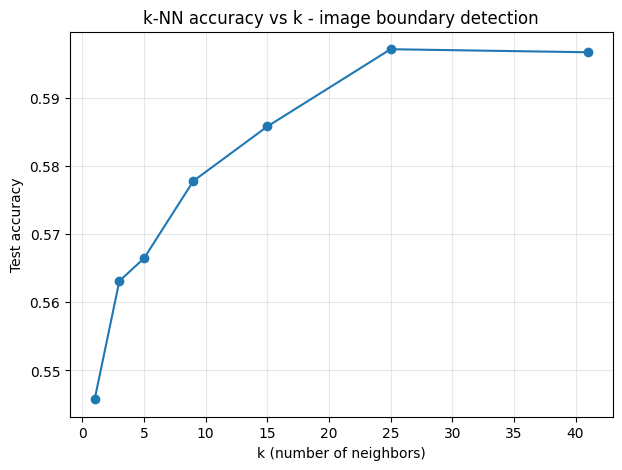

In [9]:
plt.figure(figsize=(7, 5))
plt.plot(k_values, accuracies, marker="o")
plt.xlabel("k (number of neighbors)")
plt.ylabel("Test accuracy")
plt.title("k-NN accuracy vs k - image boundary detection")
plt.grid(alpha=0.3)
plt.show()